In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.image as img
from matplotlib.image import imread
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

import cv2
import pickle

In [2]:
import matplotlib.pyplot as plt 
plt.rcParams.update({
    "font.family" : 'Arial',   # specify font family here
    "font.size" : 12,
    "font.weight" : "normal"})          # specify font size here

In [3]:
base_path = '/home/jinny/projects/Art-history/Art-history/datas/'
file_info = pd.read_csv(base_path+'file_info.csv')

# file_info_latent
df = pd.DataFrame(( np.load(base_path+'vectors/avec_latents.npy', allow_pickle=True)),columns=['avec','Path'])
file_info_latents = pd.merge(file_info, df, how = 'left', on = 'Path')
file_info_latents = file_info_latents[~file_info_latents.avec.isnull()]

avec = np.array([i.reshape(-1) for i in file_info_latents['avec']])

In [4]:
df = pd.DataFrame(np.load(base_path+'vectors/cvec_latents.npy', allow_pickle=True),columns=['cvec','Path'])
file_info_latents = pd.merge(file_info_latents, df, how = 'left', on = 'Path')

cvec = np.array([i.reshape(-1) for i in file_info_latents['cvec']])

### graph-a

In [5]:
## #sandro botticelli #titian #jan van eyck #pietro lorenzetti
r_painting = ['The Birth Of Venus 1485', 'Rape Of Europe 1562', 'The Arnolfini Wedding The Portrait', 'Madonna Enthroned With Angels 1340']

In [6]:
## #edvard munch #georges seurat #gustav #klimt #egon schiele
pi_painting = ['The Scream 1895', 'Sunday Afternoon On The Island Of La Grande Jatte 1886', 'The Kiss 1908', 'Self Portrait With Chinese Lantern Fruits 1912']

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(10, 10))
ax = ax.reshape(-1)

for i in range(4) :
    path = file_info_latents['Path'][file_info_latents['painting_name'].str.contains(pi_painting[i])].values[0]
    img = imread(base_path+"resized_image/"+path)
    ax[i].imshow(img)
    ax[i].axis('off')
fig.tight_layout()
plt.savefig('graph/figure01_A2.svg',bbox_inches='tight',transparent = True,dpi=600)

# umap

In [ ]:
avec_umap = pickle.load((open(base_path+'models/avec_umap.sav', 'rb')))
cvec_umap = pickle.load((open(base_path+'models/cvec_umap.sav', 'rb')))

In [ ]:
avecs = avec_umap.transform(avec)
avecs  = pd.DataFrame(avecs,columns=['x','y'])
avecs['new_date_detail']= file_info_latents['new_date_detail']
avecs['new_date'] = list(file_info_latents['new_date'])
avecs['author_name'] = list(file_info_latents['author_name'])
avecs['Style'] = list(file_info_latents['Style'])
avecs['Path'] = list(file_info_latents['Path'])
avecs['Genre'] = list(file_info_latents['Genre'])

In [ ]:
cvecs = cvec_umap.transform(cvec)
cvecs  = pd.DataFrame(cvecs,columns=['x','y'])
cvecs['new_date_detail']= file_info_latents['new_date_detail']
cvecs['new_date']= file_info_latents['new_date']
cvecs['author_name']= file_info_latents['author_name']
cvecs['Style'] = list(file_info_latents['Style'])
cvecs['Path']= file_info_latents['Path']
cvecs['Genre']= file_info_latents['Genre']

### graph-b

In [ ]:
def vec2img_date(date1,date2,date3,x1,x2,y1,y2) :
    dates = [date1,date2,date3]
    points = list()
    df = avecs.copy()
    df = df[(df['x']<x2)&(df['x']>x1)&(df['y']<y2)&(df['y']>y1)]

    plt.figure(figsize=(10, 10))
    for i,date in enumerate(dates) :
        temp = df[df['new_date']==date]
        temp = temp.sample(n=1,random_state=505)
        
        plt.subplot(1, 3, i + 1)
        img = imread(base_path+"resized_image/"+temp['Path'].values[0])
        plt.imshow(img)
        plt.axis('off')
        
        points.append(temp['Path'].values[0])
    return points

In [ ]:
def vec2img_date_ac_ver(date,xa1,xa2,ya1,ya2,xc1,xc2,yc1,yc2) :
    df = avecs.copy()
    df_a = df[(df['x']<xa2)&(df['x']>xa1)&(df['y']<ya2)&(df['y']>ya1)]

    df = cvecs.copy()
    df = df[df['Path'].isin(df_a['Path'])]
    df_c = df[(df['x']<xc2)&(df['x']>xc1)&(df['y']<yc2)&(df['y']>yc1)]

    plt.figure(figsize=(10, 10))
    temp = df_c[df_c['new_date']==date]
    temp = temp['Path'].values[1]

    img = imread(base_path+"resized_image/"+temp)
    plt.imshow(img)
    plt.axis('off')
    
    return temp

In [ ]:
points_A = vec2img_date(1340,1650,1950,0,2,2,4)
points_B = vec2img_date(1300,1650,1950,4,6,1,2)
points_C = vec2img_date(1300,1650,1950,7.5,10,0,1.5)

# points_B_2 = vec2img_date_ac_ver(1630,5,6,1.5,2.5,0,1,0,1)
# points_B[1] = points_B_2

points = [points_A,points_B,points_C]

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(1,1, figsize=(11, 9))
ax.patch.set_facecolor('white')

## umap
sns.scatterplot(x='x',y='y', data=avecs, hue='new_date',alpha=0.5, s=3, palette="Spectral_r",linewidth=0, edgecolor=None)
for point in points :
    temp = avecs[avecs['Path'].isin(point)]
    #temp_p = avecs['Path'].values[0]
    sns.scatterplot(x='x',y='y', data=temp, hue='new_date', s=70, palette='Spectral_r', edgecolor='black', linewidth=1, marker='s')  
ax.set_title(f"A-vector",fontsize=34, pad=20)
ax.legend(title='Date',loc = 'upper right').remove()
ax.set_xlim(avecs.x.min()-0.2, avecs.x.max()+0.2)
ax.set_ylim(avecs.y.min()-2, avecs.y.max()+2)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

## image
# left
for i in range(3):
    axins = inset_axes(ax, width="8.5%", height="8.5%", loc='upper left',
                       bbox_to_anchor=(-0.01+i*0.155, -1, 2, 2),
                       bbox_transform=ax.transAxes)
    axins.set_facecolor('darkblue')  # 일단 네모박스를 파란색으로 설정
    temp = avecs[avecs['Path'] == points[0][i]]
    img = imread(base_path+"resized_image/"+temp['Path'].values[0])
    axins.imshow(img)
    axins.axis('off')
    # 이미지 아래에 숫자 추가
    axins.text(0.5, -0.25, str(temp['new_date'].values[0]), transform=axins.transAxes, fontsize=26, ha='center')

    # 이미지와 점 연결
    ax.annotate('',
                xy=(temp.x.values[0], temp.y.values[0]+0.04),   # 점의 좌표
                xytext=(0.1 + i*0.155, 0.72),  # 이미지 박스의 좌표
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', lw=1.5, color='black'))
# middle
for i in range(3):
    axins = inset_axes(ax, width="8.5%", height="8.5%", loc='lower center',
                       bbox_to_anchor=(-0.65+i*0.155, 0.05, 2, 2),
                       bbox_transform=ax.transAxes)
    axins.set_facecolor('darkblue')
    temp = avecs[avecs['Path'] == points[1][i]]
    img = imread(base_path+"resized_image/"+temp['Path'].values[0])
    axins.imshow(img, zorder=1)
    axins.axis('off')
    # 이미지 테두리
    rect = Rectangle((0, 0), img.shape[1]-1, img.shape[0]-1, linewidth=13, edgecolor='r', facecolor='none', zorder=2)
    axins.add_patch(rect)
    # 이미지 아래에 숫자 추가
    axins.text(0.5, -0.25, str(temp['new_date'].values[0]), transform=axins.transAxes, fontsize=26, ha='center')
    # 이미지와 점 연결
    ax.annotate('',
                xy=(temp.x.values[0], temp.y.values[0]-0.04),   # 점의 좌표
                xytext=(0.35+i*0.155,0.264),  # 이미지 박스의 좌표
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', lw=1.5, color='black'))
# right
for i in range(3):
    axins = inset_axes(ax, width="8.5%", height="8.5%", loc='upper right',
                       bbox_to_anchor=(-1.3+i*0.155, -1, 2, 2),
                       bbox_transform=ax.transAxes)
    axins.set_facecolor('darkblue')
    temp = avecs[avecs['Path'] == points[2][i]]
    img = imread(base_path+"resized_image/"+temp['Path'].values[0])
    axins.imshow(img)
    axins.axis('off')
    # 이미지 아래에 숫자 추가
    axins.text(0.5, -0.25, str(temp['new_date'].values[0]), transform=axins.transAxes, fontsize=26, ha='center')
    # 이미지와 점 연결
    ax.annotate('',
                xy=(temp.x.values[0], temp.y.values[0]+0.04),   # 점의 좌표
                xytext=(0.6+i*0.155,0.725),  # 이미지 박스의 좌표
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', lw=1.5, color='black'))

## clolrbar
# ScalarMappable을 사용하여 색상 매핑을 생성합니다.
sm = cm.ScalarMappable(cmap='Spectral_r')
sm.set_array(range(70))
# colorbar를 추가합니다.
cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
cbar.set_label('Year', rotation=270, labelpad=30,fontsize=26)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.8)
# colorbar의 눈금과 눈금 레이블을 설정합니다.
cbar.set_ticks([0,10,20,30,40,50,60, 69])  # 예시로 0, 35, 69 설정
cbar.set_ticklabels([1300,1400,1500, 1600,1700,1800, 1900,1990])  # 예시로 숫자 변경
cbar.ax.invert_yaxis()
cbar.ax.yaxis.set_tick_params(labelsize=26)


## save
fig.tight_layout()
plt.savefig('graph/figure01_B.png',bbox_inches='tight',transparent = True,dpi=600)

### graph-c

In [ ]:
def vec2img_date_c_ver() :
    dates = [[1300+j*100+i*10 for i in range(10)] for j in range(7)]
    xp = [-1.0, -0.5, 0, 1, 2, 4, 5.5]
    yp = [0, 0.3, 0.7, 1.2, 2.2, 3.5, 4.8]
    points = list()
    df = cvecs.copy()

    plt.figure(figsize=(10, 10))
    for i,date in enumerate(dates) :
        temp = df[df['new_date'].isin(date)]
        temp = temp[(temp['x']<xp[i]+0.2)&(temp['x']>xp[i]-0.2)&(temp['y']<yp[i]+0.2)&(temp['y']>yp[i]-0.2)]
        temp = temp.sample(n=1,random_state=7)
        print(temp['new_date'].values[0])
        print(temp['Path'].values[0])
        
        plt.subplot(1, 7, i + 1)
        img = imread(base_path+"resized_image/"+temp['Path'].values[0])
        plt.imshow(img)
        plt.axis('off')
        
        points.append(temp['Path'].values[0])
    return points

In [ ]:
points_c = vec2img_date_c_ver()
points_c[0] = points_B[0]
points_c[3] = points_B[1]
points_c[6] = points_B[2]

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(11, 9))
ax.patch.set_facecolor('white')

## umap
sns.scatterplot(x='x',y='y', data=cvecs, hue='new_date',alpha=0.5, s=3, palette="Spectral_r",linewidth=0, edgecolor=None)

temp = cvecs[cvecs['Path'].isin(points_c)]
sns.scatterplot(x='x',y='y', data=temp, s=70, hue='new_date', palette="Spectral_r", edgecolor='black', linewidth=1, marker='s') 

ax.set_title(f"C-vector",fontsize=34, pad = 20)
ax.legend(title='Date',loc = 'upper right').remove()
ax.set_xlim(cvecs.x.min()-0.2, cvecs.x.max()+0.2)
ax.set_ylim(cvecs.y.min()-2.8, cvecs.y.max()+0.5)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

## image
# top
for i in range(3):
    axins = inset_axes(ax, width="8.5%", height="8.5%", loc='upper left',
                       bbox_to_anchor=(-0.02+i*0.155, -1, 2, 2),
                       bbox_transform=ax.transAxes)
    axins.set_facecolor('darkblue')  # 일단 네모박스를 파란색으로 설정
    temp = cvecs[cvecs['Path'] == points_c[i]]
    temp_path = temp['Path'].values[0]
    img = imread(base_path+"resized_image/"+temp_path)
    axins.imshow(img, zorder=1)
    axins.axis('off')
    # 이미지 테두리
    if temp_path in points_B :
        rect = Rectangle((0, 0), img.shape[1]-1, img.shape[0]-1, linewidth=13, edgecolor='r', facecolor='none', zorder=2)
        axins.add_patch(rect)

    # 이미지 아래에 숫자 추가
    axins.text(0.5, -0.3, str(temp['new_date'].values[0]), transform=axins.transAxes, fontsize=26, ha='center')

    # 이미지와 점 연결
    ax.annotate('',
                xy=(temp.x.values[0], temp.y.values[0]+0.1),   # 점의 좌표
                xytext=(0.1 + i*0.155, 0.72),  # 이미지 박스의 좌표
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', lw=1.5, color='black'))
# bottom
for i in range(4):
    axins = inset_axes(ax, width="8.5%", height="8.5%", loc='lower right',
                       bbox_to_anchor=(-1.45+i*0.155, 0, 2, 2),
                       bbox_transform=ax.transAxes)
    axins.set_facecolor('darkblue')  # 일단 네모박스를 파란색으로 설정
    temp = cvecs[cvecs['Path'] == points_c[i+3]]
    temp_path = temp['Path'].values[0]
    img = imread(base_path+"resized_image/"+temp_path)
    axins.imshow(img, zorder=1)
    axins.axis('off')
    # 이미지 테두리
    if temp_path in points_B :
        rect = Rectangle((0, 0), img.shape[1]-1, img.shape[0]-1, linewidth=13, edgecolor='r', facecolor='none', zorder=2)
        axins.add_patch(rect)
    # 이미지 아래에 숫자 추가
    axins.text(0.5, 1.05, str(temp['new_date'].values[0]), transform=axins.transAxes, fontsize=26, ha='center')

    # 이미지와 점 연결
    ax.annotate('',
                xy=(temp.x.values[0], temp.y.values[0]-0.15),   # 점의 좌표
                xytext=(0.44 + i*0.155, 0.28),  # 이미지 박스의 좌표
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', lw=1.5, color='black'))


## clolrbar
# ScalarMappable을 사용하여 색상 매핑을 생성합니다.
sm = cm.ScalarMappable(cmap='Spectral_r')
sm.set_array(range(70))
# colorbar를 추가합니다.
cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
cbar.set_label('Year', rotation=270, labelpad=30,fontsize=26)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.8)
# colorbar의 눈금과 눈금 레이블을 설정합니다.
cbar.set_ticks([0,10,20,30,40,50,60, 69])  # 예시로 0, 35, 69 설정
cbar.set_ticklabels([1300,1400,1500, 1600,1700,1800, 1900,1990])  # 예시로 숫자 변경
cbar.ax.yaxis.set_tick_params(labelsize=26)
cbar.ax.invert_yaxis()


## save
fig.tight_layout()
plt.savefig('graph/figure01_C.png',bbox_inches='tight',transparent = True,dpi=600)

# umap sub

In [ ]:
avecs['x_c'] = cvecs['x']
avecs['y_c'] = cvecs['y']

In [ ]:
#스타일 가중치 계산 및 대표 년도 추가
df_newstyle = file_info['Style'].str.split(',', expand=True)
df_newstyle = df_newstyle.melt(value_name='Style', ignore_index=False).dropna().drop(columns='variable')

temp = file_info[['new_date','Style','painting_name']].drop(columns='Style').join(df_newstyle, how='left')
temp['Weight'] = 1 / (temp.groupby('painting_name')['Style'].transform('count'))

df_newstyle = temp.dropna(subset=['Style'])

temp = df_newstyle.groupby('Style')['new_date'].agg(lambda x: x.mode().iloc[0]).reset_index()
temp.rename(columns={'new_date': 'Peak_year'}, inplace=True)

df_newstyle = df_newstyle.merge(temp, on='Style', how='left')

style_peak_year = df_newstyle[['Style','Peak_year']]
style_peak_year = style_peak_year.drop_duplicates()

new_style = list()
for i in df_newstyle['Style'] :
    year = style_peak_year['Peak_year'][style_peak_year['Style']==i].values[0]
    new_style.append(f'{i} ({year})')
df_newstyle['Style_Peak_year'] = new_style

In [ ]:
temp = df_newstyle[['Style_Peak_year','Weight']].groupby('Style_Peak_year').sum()
temp = temp.sort_values(by='Weight', ascending=False)[:10].reset_index()

styles = df_newstyle[['Style','Style_Peak_year']].drop_duplicates()
styles10 = temp['Style_Peak_year'].values

In [ ]:
df_umap_style = avecs.copy()
df_umap_style['new_style'] = df_umap_style['Style'].str.split(',')
df_umap_style = df_umap_style.explode('new_style') 

df_umap_style10 = df_umap_style[df_umap_style['new_style'].isin(styles['Style'][styles['Style_Peak_year'].isin(styles10)].unique())]
df_umap_style10['Style_Peak_year'] = df_umap_style10['new_style'].map(styles.set_index('Style')['Style_Peak_year'])

In [ ]:
#target_authors = [['Albrecht Durer (1471-1528)','albrecht durer'],['Rembrandt (1606-1669)','rembrandt'],['Johannes Vermeer (1632-1675)','johannes vermeer'],['Jean-Francois Millet (1814-1875)','jean-francois millet'],['Edouard Manet (1832-1883)','edouard manet'],['Paul Cezanne (1839-1906)','paul cezanne'],['Pierre-Auguste Renoir (1841-1919)','pierre auguste renoir'],['Vincent van Gogh (1853-1890)','vincent van gogh'],['Gustav Klimt (1862-1918)','gustav klimt'],['Egon Schiele (1890-1918)','egon schiele']]
target_authors = [['Albrecht Durer (1528)','albrecht durer'],['Rembrandt (1669)','rembrandt'],['Johannes Vermeer (1675)','johannes vermeer'],['Jean-Francois Millet (1875)','jean-francois millet'],['Edouard Manet (1883)','edouard manet'],['Paul Cezanne (1906)','paul cezanne'],['Pierre-Auguste Renoir (1919)','pierre auguste renoir'],['Vincent van Gogh (1890)','vincent van gogh'],['Gustav Klimt (1918)','gustav klimt'],['Egon Schiele (1918)','egon schiele']]

target_authors_dic = {i[1]:i[0] for i in target_authors}

df_umap_author10 = avecs[avecs['author_name'].isin(target_authors_dic.keys())]
df_umap_author10['author_name_year'] = [target_authors_dic[i] for i in df_umap_author10['author_name'] ]


### graph-de

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'Paired' 컬러 팔레트 불러오기
import matplotlib.colors as mcolors
palette = sns.color_palette("Paired") 
palette[2] = mcolors.to_rgb('#A09317')
palette[8] = mcolors.to_rgb('#872600')

# 그래프와 축 설정 (constrained_layout 제거)
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
ax = ax.reshape(-1)

# 축 설정 (배경, 테두리 등)
for i in range(2):
    ax[i].patch.set_facecolor('white')
    for spine in ax[i].spines.values():
        spine.set_linewidth(0.8)

# 스타일 리스트
styles_order = ['Northern Renaissance (1510)', 'Baroque (1630)', 'Rococo (1780)', 'Romanticism (1820)',
           'Realism (1880)', 'Impressionism (1880)', 'Post-Impressionism (1880)', 'Symbolism (1900)', 'Art Nouveau (Modern) (1910)',
           'Expressionism (1910)']

# 첫 번째 그래프
sns.scatterplot(x='x', y='y', data=df_umap_style, s=3, alpha=0.01, color='gray', edgecolor=None, ax=ax[0])
sns.scatterplot(x='x', y='y', data=df_umap_style10, hue='Style_Peak_year', alpha=0.5, hue_order=styles_order, s=6, palette=palette, edgecolor=None, ax=ax[0],linewidth=0,facecolors='none')

ax[0].set_title(f"A-vector", fontsize=45, pad=20)
ax[0].set_xlim(avecs.x.min() - 0.2, avecs.x.max() + 0.2)
ax[0].set_ylim(avecs.y.min() - 1.2, avecs.y.max() + 1.2)
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)
ax[0].get_legend().remove()

# 두 번째 그래프 (범례 없이)
sns.scatterplot(x='x_c', y='y_c', data=df_umap_style, s=3, alpha=0.01, color='gray', edgecolor=None, ax=ax[1],linewidth=0)
sns.scatterplot(x='x_c', y='y_c', data=df_umap_style10, hue='Style_Peak_year', alpha=0.5, hue_order=styles_order, s=6, palette=palette, edgecolor=None, ax=ax[1],linewidth=0)
ax[1].set_title(f"C-vector", fontsize=45, pad=20)
ax[1].set_xlim(avecs.x_c.min() - 0.2, avecs.x_c.max() + 0.2)
ax[1].set_ylim(avecs.y_c.min() - 1, avecs.y_c.max() + 0.2)
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)
ax[1].get_legend().remove()

# 그래프 간 간격 조정 (wspace 조정)
plt.subplots_adjust(wspace=0.1)  # wspace 값을 사용하여 간격을 조정합니다

# 범례를 두 그래프의 아래에 공통으로 추가
handles, labels = ax[0].get_legend_handles_labels()
legend = fig.legend(handles=handles, labels=labels, ncol=2, loc='lower center', bbox_to_anchor=(0.51, -0.62),
           fontsize=32, frameon=False, handlelength=0.8, columnspacing=0.4, markerscale=2, handletextpad=0.2, title='Style Periods', title_fontsize=36)
legend.get_title().set_position((0, 18))

plt.savefig('graph/figure01_DE.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

### graph-fg

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcl
import matplotlib as mpl

# 'Paired' 컬러 팔레트 불러오기
import matplotlib.colors as mcolors
palette = sns.color_palette("Paired") 
palette[2] = mcolors.to_rgb('#A09317')
palette[8] = mcolors.to_rgb('#872600')

# 그래프와 축 설정 (constrained_layout 제거)
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
ax = ax.reshape(-1)

# 축 설정 (배경, 테두리 등)
for i in range(2):
    ax[i].patch.set_facecolor('white')
    for spine in ax[i].spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)

sns.scatterplot(x='x',y='y', data=df_umap_style, s=3,alpha=0.01, color='gray', ax=ax[0],edgecolor=None)
sns.scatterplot(x='x',y='y', data=df_umap_author10, hue='author_name_year',alpha=0.9,hue_order=target_authors_dic.values(), s=6, palette=palette, ax=ax[0],edgecolor=None)
ax[0].set_title(f"A-vector",fontsize=45, pad=20)
ax[0].set_xlim(avecs.x.min()-0.2, avecs.x.max()+0.2)
ax[0].set_ylim(avecs.y.min()-1.2, avecs.y.max()+1.2)
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)
ax[0].get_legend().remove()

sns.scatterplot(x='x_c',y='y_c', data=df_umap_style, s=5,alpha=0.01, color='gray', ax=ax[1], edgecolor=None)
sns.scatterplot(x='x_c',y='y_c', data=df_umap_author10, hue='author_name_year',alpha=0.9,hue_order=target_authors_dic.values(), s=6, palette=palette, ax=ax[1], edgecolor=None)
ax[1].set_title(f"C-vector", fontsize=45, pad=20)
ax[1].set_xlim(avecs.x_c.min() - 0.2, avecs.x_c.max() + 0.2)
ax[1].set_ylim(avecs.y_c.min()-1, avecs.y_c.max()+0.2)
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)
ax[1].get_legend().remove()

# 그래프 간 간격 조정 (wspace 조정)
plt.subplots_adjust(wspace=0.1)  # wspace 값을 사용하여 간격을 조정합니다

# 범례를 두 그래프의 아래에 공통으로 추가
handles, labels = ax[0].get_legend_handles_labels()
legend = fig.legend(handles=handles, labels=labels, ncol=2, loc='lower center', bbox_to_anchor=(0.51, -0.62),
           fontsize=32, frameon=False, handlelength=0.8, columnspacing=0.4, markerscale=2, handletextpad=0.2, title='Painting Artists', title_fontsize=36)
legend.get_title().set_position((0, 18))

plt.savefig('graph/figure01_FG.png',bbox_inches='tight',transparent = True,dpi=600)

# Reression

### graph-hi

In [9]:
# cvec_xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.08, gamma=0, subsample=0.75,
#                            colsample_bytree=1, max_depth=7)
# cvec_xgb_model.fit(X_train, y_train)
# cvec_xgb_model.save_model(base_path+"models/cvec_xgb_model.json") 

# 모델 불러오기
cvec_xgb_model = xgb.XGBRegressor()
cvec_xgb_model.load_model(base_path+"models/cvec_xgb_model.json")

In [10]:
y_pre_cvec = cvec_xgb_model.predict(X_test)

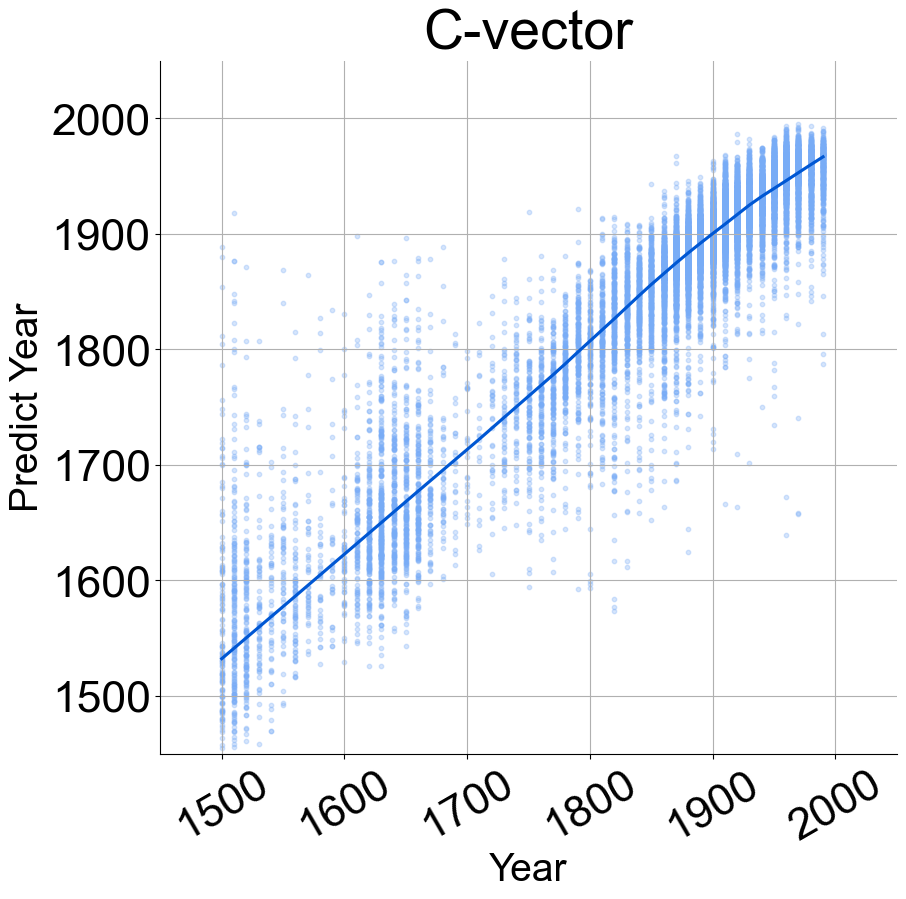

In [11]:
# 산점도 및 회귀선 그리기
fig, ax = plt.subplots(figsize=(9.5, 9))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sns.regplot(x=y_test, y=y_pre_cvec, scatter_kws={'s': 10,'alpha':0.3, 'color':'#78ACF6'}, line_kws={'color': '#0057D3'}, ax=ax, lowess=True )

plt.xlabel('Year',fontsize=28)  # x축 레이블 설정
plt.ylabel('Predict Year',fontsize=28)
plt.xlim(-5, 55)
plt.ylim(-5, 55)
plt.xticks([0, 10, 20, 30, 40, 50], [1500, 1600, 1700, 1800, 1900, 2000],fontsize=32, rotation=30)
plt.yticks([0, 10, 20, 30, 40, 50], [1500, 1600, 1700, 1800, 1900, 2000],fontsize=32)
plt.grid(True)
plt.title('C-vector', fontsize=40)

plt.savefig('graph/figure01_I.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [12]:
df_test = pd.DataFrame({'y_test':y_test,'y_pre':y_pre_cvec})

corr_s = spearmanr(y_test, y_pre_cvec).correlation
corr_p = pearsonr(y_test, y_pre_cvec)[0]
mae = mean_absolute_error(y_test, y_pre_cvec)
rmse = np.sqrt(mean_squared_error(y_test, y_pre_cvec))
tau, p_value = kendalltau(y_test, y_pre_cvec)

print('------C-vector------')
print(f'Correlation_spearman: {corr_s}')
print(f'Correlation_pearson: {corr_p}')
print(f'r2_score : {r2_score(y_test, y_pre_cvec)}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'Kendall tau : {tau}, p-value : {p_value}')

------C-vector------
Correlation_spearman: 0.8914827104476879
Correlation_pearson: 0.9342956288617863
r2_score : 0.8725092244985189
MAE: 2.3028
RMSE: 3.7500
Kendall tau : 0.7466841239029199, p-value : 0.0


In [37]:
df_test.to_csv('C-vector_regression.csv')

In [132]:
df_predicts = pd.read_csv("datas/models/xgboosts_regression/predicts.csv")
df_trains = pd.read_csv("datas/models/xgboosts_regression/trains.csv")
df_metrics = pd.read_csv("datas/models/xgboosts_regression/metrics.csv")

In [133]:
best_seed = df_metrics['seed'][df_metrics['pearson'] == df_metrics['pearson'].max()].values[0]

In [140]:
best_seed

3337

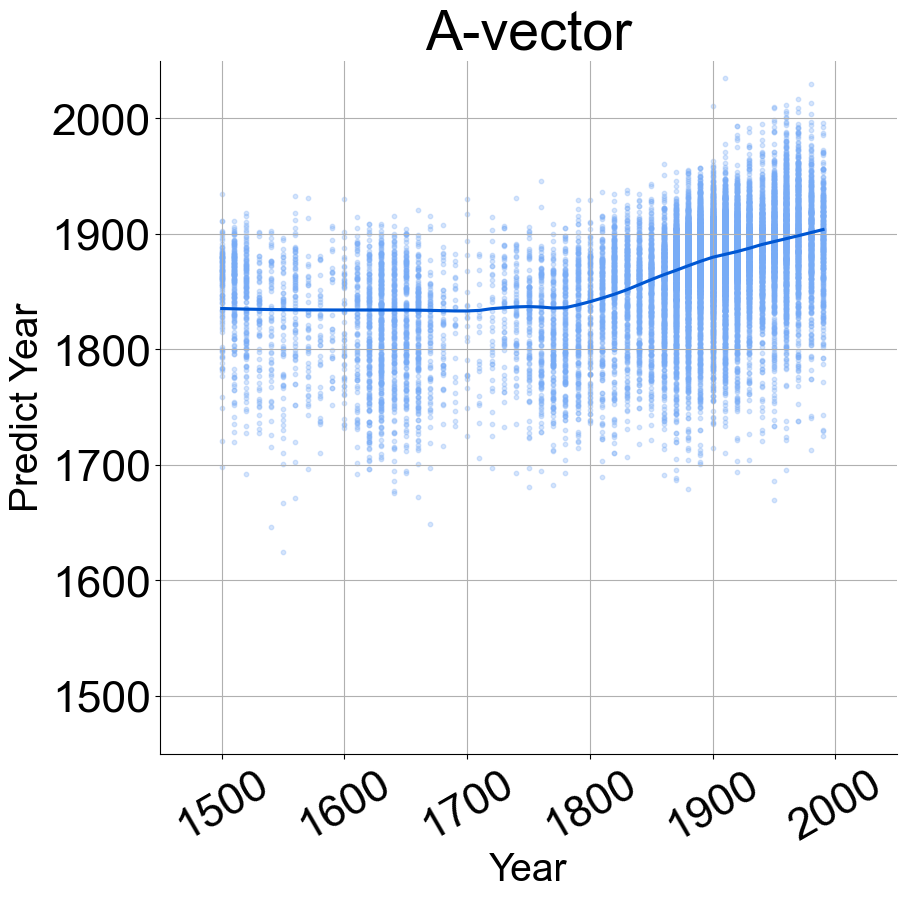

In [137]:
# 산점도 및 회귀선 그리기
fig, ax = plt.subplots(figsize=(9.5, 9))
# 위쪽과 오른쪽 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_test = df_predicts[[f'seed_{best_seed}_y_test_year']]
y_pre_avec = df_predicts[[f'seed_{best_seed}_A_pred_year']]

sns.regplot(x=y_test, y=y_pre_avec, scatter_kws={'s': 10,'alpha':0.3, 'color':'#78ACF6'}, line_kws={'color': '#0057D3'}, ax=ax, lowess=True)

plt.xlabel('Year',fontsize=28)  # x축 레이블 설정
plt.ylabel('Predict Year',fontsize=28)
plt.xlim(1450, 2050)
plt.ylim(1450, 2050)
plt.xticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32, rotation=30)
plt.yticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32)
plt.grid(True)
plt.title('A-vector', fontsize=40)
plt.savefig('graph/figure01_H.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

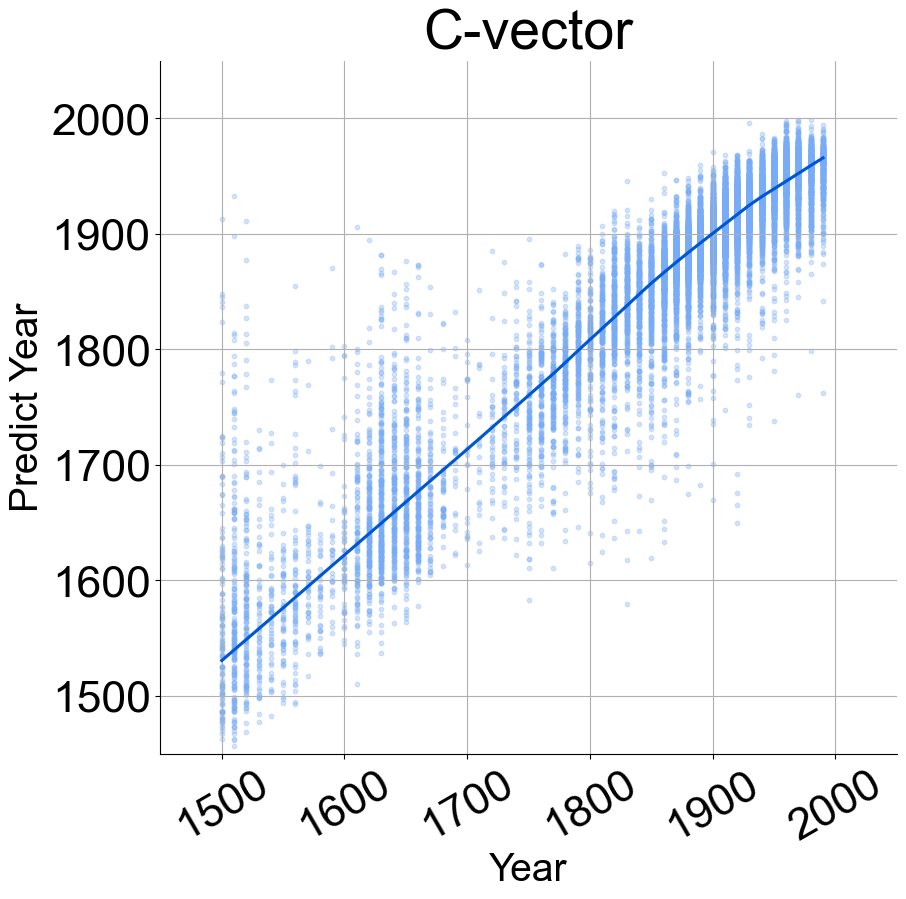

In [138]:
# 산점도 및 회귀선 그리기
fig, ax = plt.subplots(figsize=(9.5, 9))
# 위쪽과 오른쪽 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_test = df_predicts[[f'seed_{best_seed}_y_test_year']]
y_pre_cvec = df_predicts[[f'seed_{best_seed}_C_pred_year']]

sns.regplot(x=y_test, y=y_pre_cvec, scatter_kws={'s': 10,'alpha':0.3, 'color':'#78ACF6'}, line_kws={'color': '#0057D3'}, ax=ax, lowess=True)

plt.xlabel('Year',fontsize=28)  # x축 레이블 설정
plt.ylabel('Predict Year',fontsize=28)
plt.xlim(1450, 2050)
plt.ylim(1450, 2050)
plt.xticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32, rotation=30)
plt.yticks([1500, 1600, 1700, 1800, 1900, 2000],fontsize=32)
plt.grid(True)
plt.title('C-vector', fontsize=40)
plt.savefig('graph/figure01_I.png',bbox_inches='tight',transparent = True,dpi=600)
plt.show()

In [139]:
df_metrics[df_metrics['seed']==best_seed]

,seed,vector,pearson,spearman,mae,rmse,r2
108,3337,C,0.935804,0.888471,2.288178,3.706918,0.875032
109,3337,A,0.451526,0.477782,6.146521,9.360029,0.203243


In [145]:
df_metrics[df_metrics['vector']=='A'].describe().to_csv('datas/models/xgboost_regression_A.csv')

In [156]:
df_metrics[df_metrics['vector']=='C'].describe().to_csv('datas/models/xgboost_regression_C.csv')